#### Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import SkyCoord, EarthLocation, AltAz

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

# Ligo-SkyMap
import ligo.skymap.plot
from ligo.skymap.io.fits import read_sky_map

# Tilepy utilities
# from tilepy.include.PointingTools import getdate
from tilepy.include.ObservationScheduler import GetSchedule
from tilepy.include.CampaignDefinition import ObservationParameters

import utils
import find_skymap

class ProcessingError(Exception):
    """Custom exception for expected processing failures."""
    pass
    
from tilepy import __version__ as tilepy_version
print(f"Using Tilepy version: {tilepy_version}")

Using Tilepy version: 3.0.2.dev47+g31c804d84


## Input parameters

In [2]:
event_name = "GW190412" # oda:String ; oda:label "Gravitational Wave Event" ; oda:description "Name of the gravitational wave event (e.g., GW190412, GW190425, GW170817)"
instrument = "LST" # oda:String ; oda:allowed_value 'LST','CTAOS','CTAON','MAGIC','HESS' ; oda:label "Instrument" ; oda:description "Name of the instrument to be simulated"

In [3]:
if not event_name or not isinstance(event_name, str):
    raise ProcessingError("Event name must be a non-empty string.")

# Other secundary parameters ---
resolution_hp_to_grid = 2048
threshold_percent_gw = [0.95, 0.5]

config_tilepy = os.path.join("followup_parameters", f"FollowupParameters_{instrument}.ini")

if not os.path.exists(config_tilepy):
    raise ProcessingError(f"Configuration file not found: {config_tilepy}. Please ensure the followup parameters file exists for the selected instrument.")

dict_sites = {
    "MAGIC" : "Roque de Los Muchachos",
    "CTAON" : "Roque de Los Muchachos",
    "CTAOS" : "Cerro Paranal",
    "LST"   : "Roque de Los Muchachos",
}
    
if instrument == "HESS": # HESS site is not in astropy database
    coords_site = EarthLocation.from_geodetic(lon=16.4989369*u.deg, lat=-23.2716558*u.deg, height=1850*u.m)
else: 
    coords_site = EarthLocation.of_site(dict_sites[instrument])

### Retrieving GW information and formatting data geom

Searching GWTC Catalog for GW190412
 - Found in GWTC: data/IGWN-GWTC2p1-v2-GW190412_053044_PEDataRelease_cosmo_reweight_C01:IMRPhenomXPHM.fits



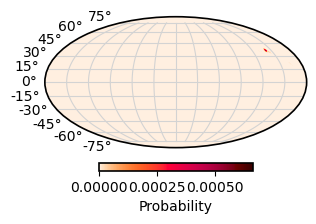

In [4]:
# Finding the file and copying it
if event_name == "GW170817" or event_name == "G298048":
    # GW170817 is not in GWTC as exception, and
    # G298048 is the graaceDB name for the same event
    import urllib.request
    skymap_url = "https://dcc.ligo.org/public/0157/P1800381/007/GW170817_skymap.fits.gz"
    # skymap_url = "https://dcc.ligo.org/public/0157/P1800381/007/GW170817_skymap.fits"
    data_folder = "./data/"
    os.makedirs(data_folder, exist_ok=True)

    local_path = os.path.join(data_folder, "GW170817_bayestar.fits.gz")
    try:
        print(f"Downloading public skymap for {event_name} from {skymap_url}")
        urllib.request.urlretrieve(skymap_url, local_path)
        file_skymap = local_path
        print(f"Downloaded to: {file_skymap}\n")
    except Exception as e:
        raise ProcessingError(f"Failed to download public skymap for {event_name}: {str(e)}")
else:
    file_skymap = find_skymap.get_skymap(event_name)

if file_skymap is None:
    raise ProcessingError(f"No skymap found for event '{event_name}'. Please check the event name and ensure it exists in GWTC or GraceDB.")

# Reading and formatting the data
# Extracting coordinates from healpy
ra_bins  = np.linspace(-180, 180, resolution_hp_to_grid)
dec_bins = np.linspace(-90, 90, resolution_hp_to_grid)
ra_grid, dec_grid = np.deg2rad(np.meshgrid(ra_bins, dec_bins))

# Reading GW data and converting to 2D geometry
data_ligo_hp, meta_ligo_hp = read_sky_map(file_skymap)
data_ligo_2d = utils.healpix2map(data_ligo_hp, ra_bins, dec_bins)

# Getting the thresholds for probability containment and hotspot
threshold_percent_gw = np.flip(np.sort(threshold_percent_gw))
threshold_maps = utils.get_hp_map_thresholds(data_ligo_hp, threshold_percent_gw)
hotspot_coord = utils.get_2d_map_hotspot(data_ligo_2d, ra_bins, dec_bins)

find_skymap.plot_gw(ra_grid, dec_grid, data_ligo_2d)

### Getting the tiling

In [5]:
# Tilepy parameters ---
obsTime = find_skymap.get_event_time(file_skymap)[0]
pointingsFile = None
datasetDir = "./data/" # Path to the input datasets (where galaxy cat should be for GW case)
outDir = "./output_tilepy/" # Path to the output folder
galcatName = None # GalCat Name

Starting the 2D pointing calculation with the following parameters

Filename:  undefined
Date: 2019-04-12 05:30:44.181992
Previous pointings: None
Dataset: ./data/
Output: ./output_tilepy//undefined
90% area = 24.70670668090373. 50% area = 4.009594250364285

Obspar:
============== Observation Parameters ======================
Observatory Name: LST
Event Name: undefined
obsTime: 2019-04-12 05:30:44.181992
---------------------- Strategy ----------------------
Algorithm = 3D, Strategy = integrated,  Mangrove = False
Do Plot = True, Do Rank = True, Count Previous= True, Second Round= False, Use Grey Time= False
--------------------- Observatory ---------------------
Observatory Location: 28.761944 deg, -17.89 deg, 2200.0 m
Wobble Offset: 0.0 deg
FOV: 2.0, Duration: 20.0, Min Duration: 10.0, Min Slewing: 0.0
Max Runs: 4, Max Nights: 1
Visibility: -18, -0.5, 65, 0, 0.0
Min Moon Source Separation: 30
Max Moon Source Separation: 145
Geomagnetic Threshold for SAA: 0
Max Zenith: 60, Zenith Weig

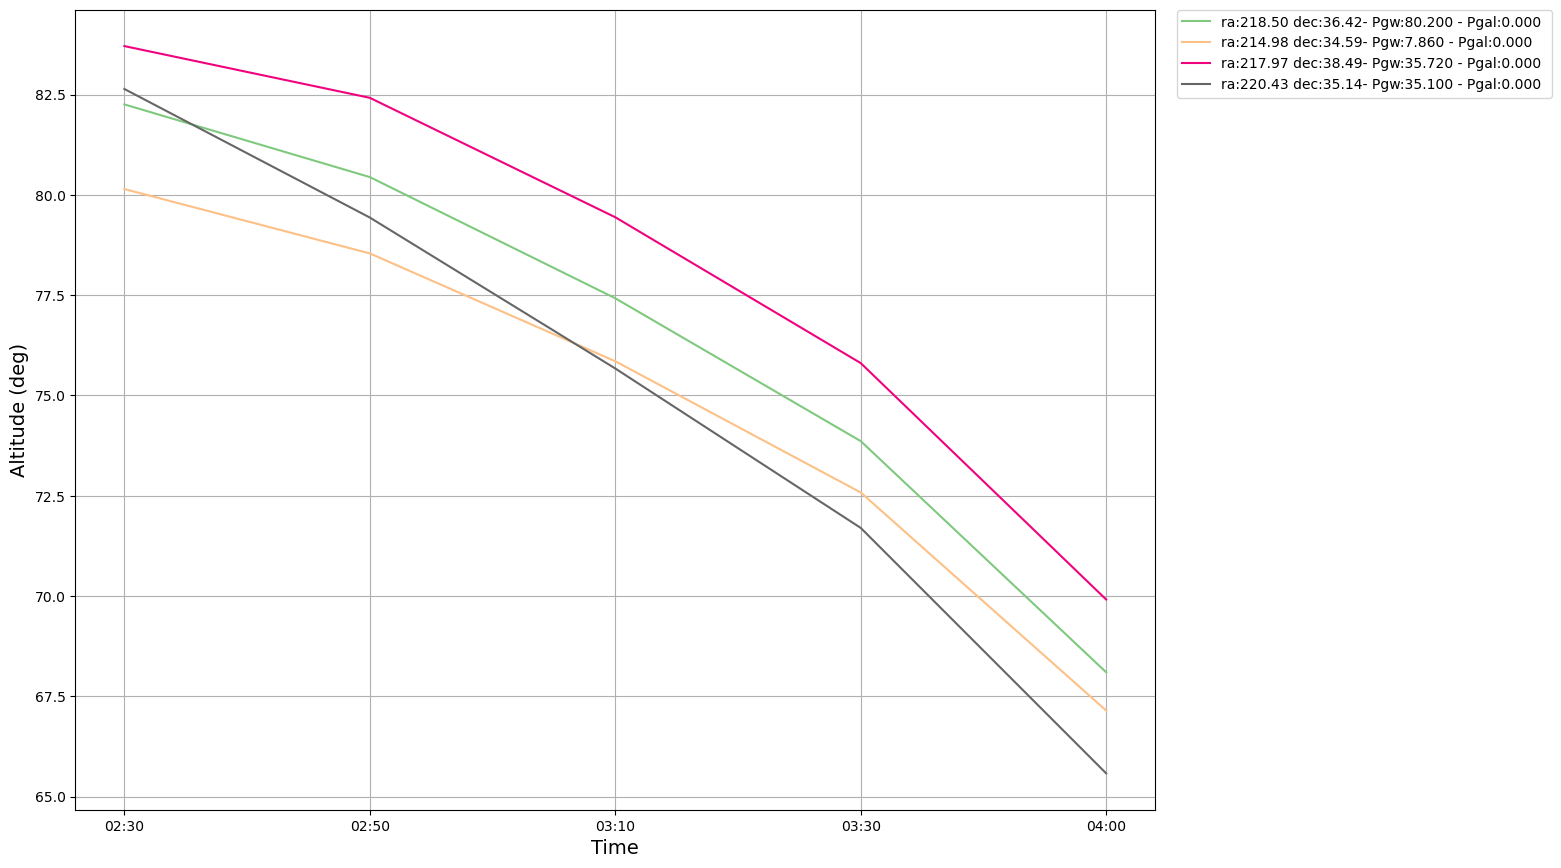

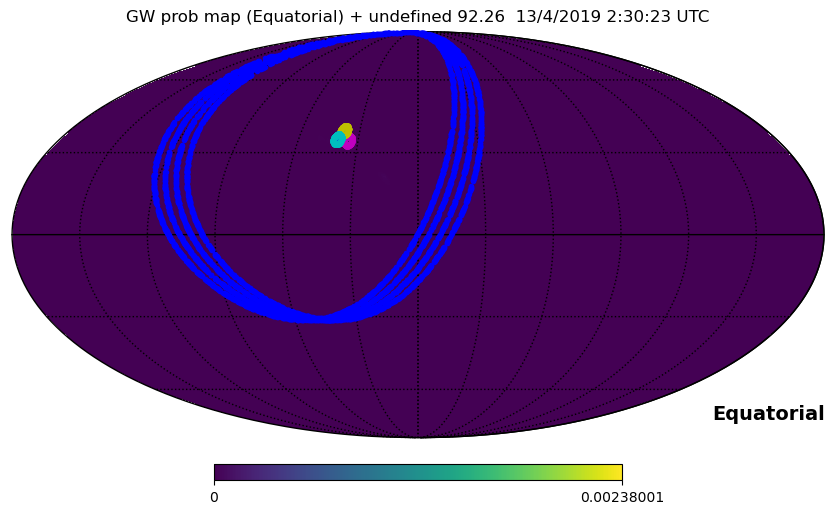

In [6]:
# Parse the parameters
obspar = ObservationParameters()
obspar.add_parsed_args(
    file_skymap, obsTime, datasetDir, galcatName, outDir, pointingsFile
)
obspar.from_configfile(config_tilepy)
    
display(obspar)

# We run tilepy over the SkyMap and the parameters
try:
    GetSchedule(obspar)
except Exception as e:
    raise ProcessingError(f"Failed to generate pointing schedule: {str(e)}. Please check the input parameters and configuration file.")

In [7]:
print(f"Dataset Dir: {obspar.datasetDir}")
print(f"Galaxy Cat: {obspar.galcatName}")
print(f"Strategy: {obspar.strategy}")

# If any of these are 'None', the concatenation on line 113 will fail.

Dataset Dir: ./data/
Galaxy Cat: None
Strategy: integrated


In [9]:
event_name_tilepy = getattr(obspar, "event_name", "undefined") 
out_dir = obspar.outDir

# Construct the path based on the log output pattern
final_pointing_path = os.path.join(
    out_dir, event_name_tilepy, "PGinFoV", "SuggestedPointings_2DProbOptimisation.txt"
); print(f"Generated pointing file at: {final_pointing_path}\n")

final_png_path = os.path.join(
    out_dir, event_name_tilepy, "PGinFoV", f"Plot_PrettyMap_{event_name_tilepy}.png"
); print(f"Generated summary map PNG at: {final_png_path}\n")

try:
    from astropy.table import Table
    from astropy.coordinates import SkyCoord, EarthLocation, AltAz
    from astropy.time import Time
    
    # Read CSV into astropy Table
    table = Table.read(final_pointing_path, format='ascii.basic')
    
    # Clean up column names and extract units
    for col in table.colnames:
        # Extract unit from brackets if present
        if '[' in col and ']' in col:
            start = col.index('[') + 1
            end = col.index(']')
            unit_str = col[start:end]
            new_col = col[:col.index('[')].strip()
            # Try to parse the unit
            try:
                table[col].unit = u.Unit(unit_str)
            except:
                pass
        else:
            new_col = col.strip()
        
        table.rename_column(col, new_col)
    
    # Computing coordinates and adding to table
    location = EarthLocation.of_site("Roque de Los Muchachos")
    time = Time(obsTime)
    coords = SkyCoord(ra=table["RA"], dec=table["DEC"], unit="deg")
    altaz = coords.transform_to(AltAz(obstime=time, location=location))
    
    table["ZD"] = 90 - altaz.alt.deg
    table["ZD"].unit = u.deg
    table["ALT"] = altaz.alt.deg
    table["ALT"].unit = u.deg
    table["AZ"] = altaz.az.deg
    table["AZ"].unit = u.deg
    
    display(table)
    
    if not os.path.exists(final_png_path):
        raise ProcessingError(f"Summary map PNG not found at {final_png_path}.")


except FileNotFoundError:
    raise ProcessingError(f"No pointing data generated. The pointing file was not found at {final_pointing_path}. This may indicate that no valid pointings were found for the given parameters.")
except Exception as e:
    raise ProcessingError(f"Failed to process pointing data: {str(e)}")

Generated pointing file at: ./output_tilepy/undefined/PGinFoV/SuggestedPointings_2DProbOptimisation.txt

Generated summary map PNG at: ./output_tilepy/undefined/PGinFoV/Plot_PrettyMap_undefined.png



Time,RA,DEC,PGW,Round,ObsName,Duration,FoV,ZD,ALT,AZ
,deg,deg,,,,,,deg,deg,deg
str19,float64,float64,float64,int64,str3,float64,float64,float64,float64,float64
2019-04-13 02:30:23,218.4961,36.4236,0.802,1,LST,20.0,2.0,39.33059004587248,50.66940995412752,293.37251603832885
2019-04-13 02:50:23,214.9805,34.5906,0.0634,1,LST,20.0,2.0,42.32593692954658,47.67406307045342,290.91638260592777
2019-04-13 03:10:23,217.9687,38.4913,0.0306,1,LST,20.0,2.0,39.699543517510186,50.300456482489814,296.6373074819708
2019-04-13 03:30:23,220.4297,35.1361,0.0266,1,LST,20.0,2.0,37.825610521227894,52.174389478772106,291.1890733253807


In [10]:
skymap_fits_output = file_skymap  # http://odahub.io/ontology#FITSFile ; oda:label "GW Skymap" ; oda:description "Gravitational wave probability skymap in FITS format"
pointings_table_output = table  # http://odahub.io/ontology#ODAAstropyTable ; oda:label "Suggested Pointings" ; oda:description "Astropy table with suggested pointing positions, coordinates (RA/DEC), and zenith angles computed for the observation site"
summary_map_png_output = final_png_path  # http://odahub.io/ontology#ODAPictureProduct ; oda:label "Summary Map" ; oda:description "Summary map visualization of the GW probability sky map with suggested pointing positions"